In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [189]:
df = pd.read_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_post_feature_selection.csv')

In [190]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 83,1.18,3,3,2,relatively new,1612.0,0,0,unfurnished,budget,high-rise
1,flat,sector 62,4.00,3,3,3,new,2353.0,1,0,semifurnished,budget,high-rise
2,flat,sector 85,1.10,2,2,3+,relatively new,1459.0,0,1,unfurnished,luxury,low-rise
3,flat,sector 91,0.89,2,2,3+,relatively new,1297.0,0,0,semifurnished,budget,medium-rise
4,flat,sector 7,0.48,3,2,1,new,889.0,0,0,unfurnished,budget,low-rise


In [191]:
df['price'].describe()

count    3499.000000
mean        2.482904
std         2.809377
min         0.080000
25%         0.990000
50%         1.550000
75%         2.650000
max        31.500000
Name: price, dtype: float64

In [188]:
df = df[df['price'] < 20]

In [192]:
df[df['price'] >20 ]

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
251,house,sector 43,27.5,6,7,3+,relatively new,11286.00,1,0,semifurnished,budget,low-rise
345,house,sector 54,25.0,4,4,3+,relatively old,8035.74,1,1,unfurnished,semi-luxury,low-rise
795,house,sector 48,22.0,5,6,3,relatively old,8249.90,1,0,unfurnished,semi-luxury,low-rise
1736,house,sector 26,23.0,4,4,3+,relatively new,9000.00,1,1,semifurnished,luxury,low-rise
3257,house,sector 26,31.5,7,9,3+,relatively old,9000.00,1,1,furnished,semi-luxury,low-rise


In [143]:
df['built_up_area'].describe()

count     3492.000000
mean      1893.310782
std       1180.597146
min         33.000000
25%       1245.000000
50%       1650.000000
75%       2225.000000
max      12222.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

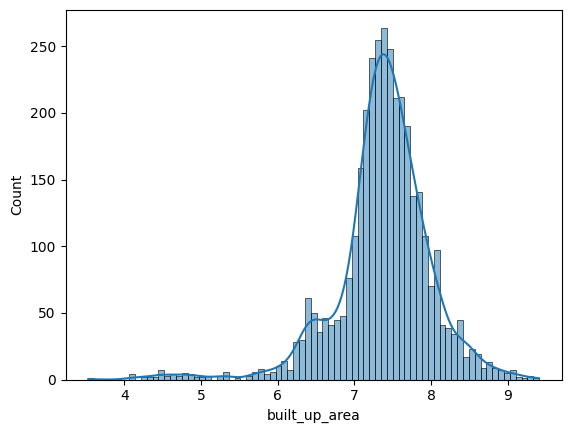

In [161]:
sns.histplot((np.log1p(df['built_up_area'])), kde = True)

<Axes: xlabel='built_up_area'>

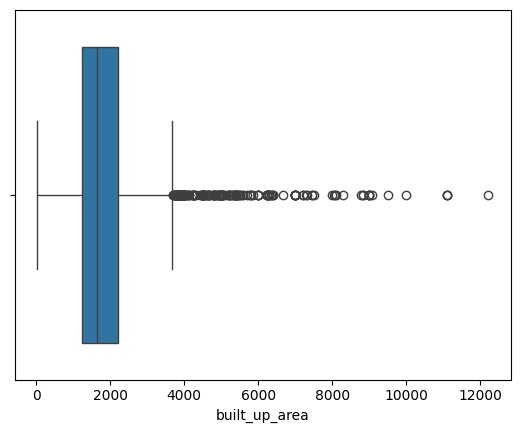

In [173]:
sns.boxplot(x = df['built_up_area'])

<Axes: xlabel='price', ylabel='Count'>

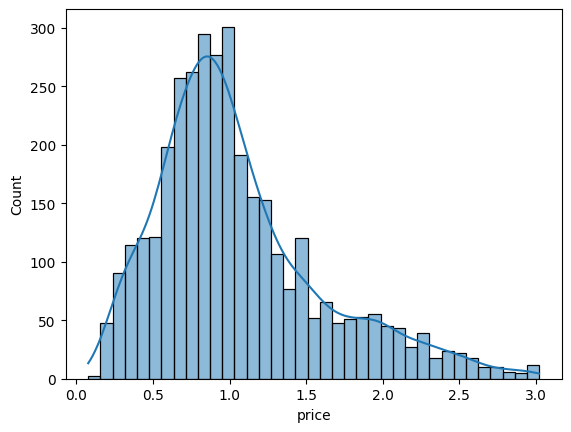

In [162]:
sns.histplot(np.log1p(df['price']), kde = True)

In [163]:
df.isnull().sum()

property_type      0
sector             0
price              0
bedRoom            0
bathroom           0
balcony            0
agePossession      0
built_up_area      0
servant room       0
store room         0
furnishing_type    0
luxury_category    0
floor_category     0
dtype: int64

In [193]:
X = df.drop(columns = 'price')
y = df['price']

# X['built_up_area'] = np.sqrt(X['built_up_area'])
y_transformed = np.log1p(y)
X['built_up_area'] = np.log1p(df['built_up_area'])**2

In [194]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, TargetEncoder

In [195]:
cat_columns_to_encode = ['property_type', 'sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

num_columns_to_encode = ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']

cat_columns_to_ohe = ['agePossession', 'furnishing_type'] 

cat_column_to_target_encode = ['sector']

In [196]:
preprocessor = ColumnTransformer([
    ('numerical_columns', StandardScaler(), num_columns_to_encode),
    ('cat_ord', OrdinalEncoder(), cat_columns_to_encode),
    ('cat_ohe', OneHotEncoder(drop='first'), cat_columns_to_ohe),
    ('target_encode', TargetEncoder(), cat_column_to_target_encode)
], remainder='passthrough')

In [197]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [198]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])

In [199]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits = 10, shuffle= True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv = kfold, scoring = 'r2')

print(scores.mean())
print(scores.std())

0.9017064265993442
0.007526910440655146


In [200]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state = 42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
print(mae)

0.5066460695078009


XGBRegressor

In [152]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor())
])

kfold = KFold(n_splits = 10, shuffle= True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv = kfold, scoring = 'r2')

print(scores.mean())
print(scores.std())

0.8979669603389029
0.01938373691581848


In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state = 42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
print(mae)

0.45698977122149925
